# Reading CARMA Results

To begin reading results, we can start by loading the carmapy object that we created in the previous tutorial.

In [10]:
import carmapy

carma = carmapy.load_carma("my_first_carma")

Note that `carmapy.load_carma()` only loads in the initial conditions of the carma run, not the results.  To also load the results we can run the following code:

In [11]:
carma.read_results()

## Ensuring Convergence
When drawing conclusions from carma results, it is critical to first ensure that the model has converged.  The fastest way to check convergence in carma is the check to see how the gas abundance at the top of the atmosphere has been changing—if the gas abundance for each species has reached a steady or stable oscillatory state, carma is most likely converged.  carmapy includes a convinience function that plots the gas abundance at the top of the atmosphere for you:

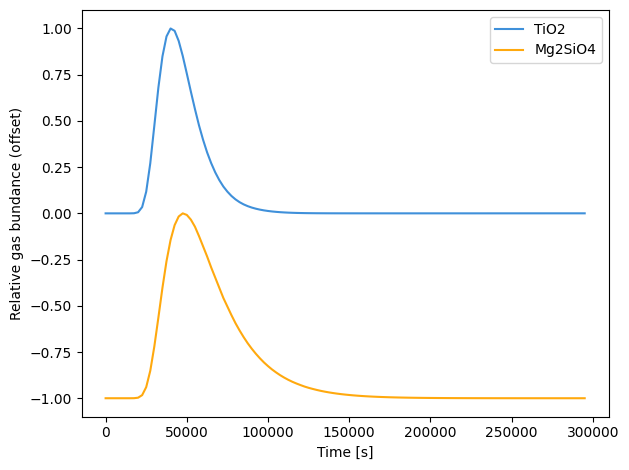

In [12]:
carma.results.plot_toa_gas(burn_in=0)

This model is plausibly converged but it would likely be useful to run it for longer to ensure convergence

## Accessing and Plotting Cloud Model Results
Cloud model results are provided in a dictionary `carma.results.clouds`.  Note as a single gas species can both homogeneously and heterogeneously condence, and could theoretically heterogeneously condense onto multiple different seed particles, carmapy automatically adjusts the names of each cloud species to distinguish between these cases:

1. If a cloud species is homogeneously nucleated from a gas species, then the name of the cloud species is "Pure \<gas species name\>" (ie "Pure TiO2")
2. If a cloud species is formed from a the heterogeneous nucleation of a gas species onto an existing cloud particle then the cloud species name is "\<gas species name\> on \<seed particle gas name\>" (ie "Mg2SiO4 on TiO2")

To see the names of all of the cloud species in a given carma run you can run:

In [13]:
carma.results.clouds.keys()

dict_keys(['Pure TiO2', 'Mg2SiO4 on TiO2'])

For each cloud species we store 3 items:
1. `numden`: a $n_z \times n_r \times n_t$ numpy array that represents the number density of particles in units of cm⁻³ where $n_z$ is the number of atmospheric "centers" (see the previous tutorial for the distinction between "centers" and "levels") and the first element in that axis corresponds to the bottom of the atmosphere, $n_r$ is the number of size bins with the first element in that axis corresponding to the minimum particle size for the species, and $n_t$ being the number of output steps, with the first element in that axis corresponding to the first output of the simulation 
2. `r`: a numpy array with $n_r$ elements which correspond to the radius, in cm, of each particle size bin
3. `r_mass` a numpy array with $n_r$ elements which correspond to the mass of particles in each radius bin

Using this output, you can plot the number density profile of TiO2 as follows:

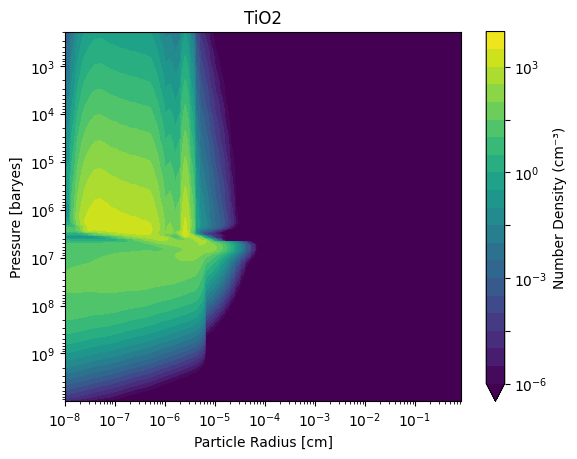

In [ ]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

t_step = -1

max_den = np.max(carma.results.clouds["Pure TiO2"]["numden"][:,:,t_step])

levels = np.logspace(int(np.log10(max_den) + 1)-10, int(np.log10(max_den) + 1), 21)

plt.contourf(carma.results.clouds["Pure TiO2"]["r"],
             carma.results.P,
             carma.results.clouds["Pure TiO2"]["numden"][:, :, t_step] + 1e-100,
             norm=matplotlib.colors.LogNorm(vmin=levels.min(), vmax=levels.max()),
             levels=levels,
             extend="min")

plt.xscale("log")
plt.yscale("log")
plt.gca().invert_yaxis()

plt.ylabel("Pressure [baryes]")
plt.xlabel("Particle Radius [cm]")


plt.colorbar(label="Number Density (cm⁻³)")
plt.title("TiO2")
plt.show()

Notice that here we use `carma.results.P` which gives the pressures the results are calculated at.  Under normal use of carmapy, this should be equivalent to `carma.results.P_centers` once results are loaded.

**Note that CARMA outputs number densities  not $dN/d\ln r$.** If you instead wanted to plot that you can divide the number densityies by the ratio between subsequent bins, which is a constant for CARMA runs.  For example:

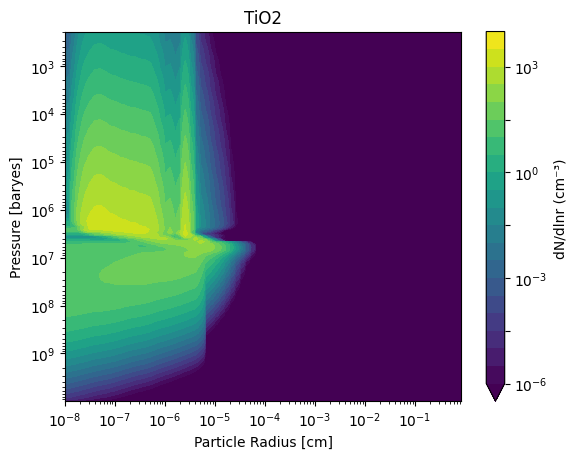

In [ ]:

t_step = -1
r = carma.results.clouds["Pure TiO2"]["r"]

dlnr =r[1] / r[0]

max_den = np.max(carma.results.clouds["Pure TiO2"]["numden"][:,:,t_step]/dlnr)

levels = np.logspace(int(np.log10(max_den) + 1)-10, int(np.log10(max_den) + 1), 21)

plt.contourf(carma.results.clouds["Pure TiO2"]["r"],
             carma.results.P,
             (carma.results.clouds["Pure TiO2"]["numden"][:, :, t_step]/dlnr + 1e-100),
             norm=matplotlib.colors.LogNorm(vmin=levels.min(), vmax=levels.max()),
             levels=levels,
             extend="min")

plt.xscale("log")
plt.yscale("log")
plt.gca().invert_yaxis()

plt.ylabel("Pressure [baryes]")
plt.xlabel("Particle Radius [cm]")


plt.colorbar(label="dN/dlnr (cm⁻³)")
plt.title("TiO2")
plt.show()

If instead of number density, you wanted to plot the mass density of the clouds you can do so by multiplying the number density array by the `r_mass` array.  For example:

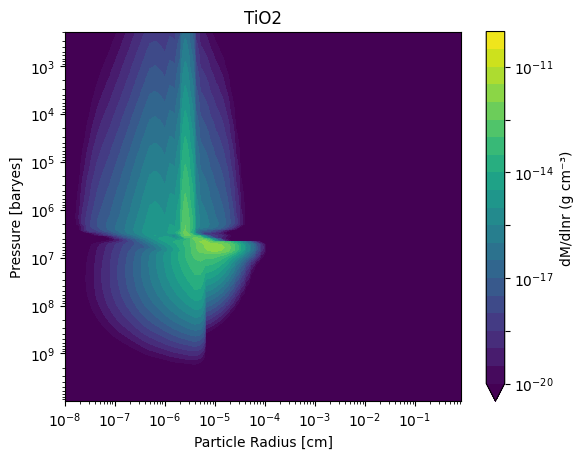

In [ ]:

t_step = -1
r = carma.results.clouds["Pure TiO2"]["r"]

dlnr = r[1] / r[0]

mass_density = (carma.results.clouds["Pure TiO2"]["numden"][:,:,t_step]
                * carma.results.clouds["Pure TiO2"]["r_mass"]
                / dlnr
                + 1e-100)

max_den = np.max(mass_density)

levels = np.logspace(int(np.log10(max_den) + 1)-10, int(np.log10(max_den) + 1), 21)

plt.contourf(carma.results.clouds["Pure TiO2"]["r"],
             carma.results.P,
             mass_density,
             norm=matplotlib.colors.LogNorm(vmin=levels.min(), vmax=levels.max()),
             levels=levels,
             extend="min")

plt.xscale("log")
plt.yscale("log")
plt.gca().invert_yaxis()

plt.ylabel("Pressure [baryes]")
plt.xlabel("Particle Radius [cm]")


plt.colorbar(label="dM/dlnr (g cm⁻³)")
plt.title("TiO2")

plt.show()

For completeness, here is the same plot but instead for the Mg₂SiO₄ on TiO₂ clouds:

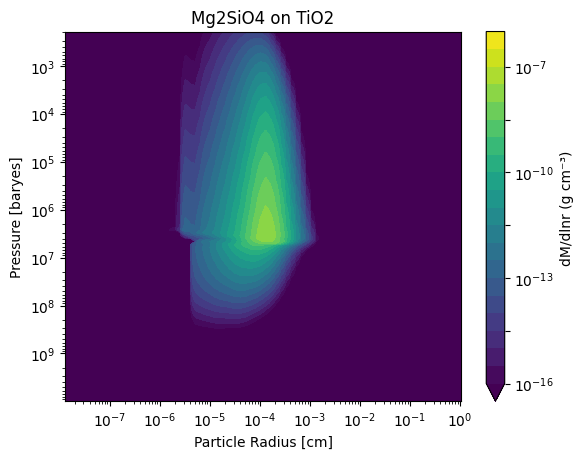

In [ ]:
t_step = -1
r = carma.results.clouds["Mg2SiO4 on TiO2"]["r"]

dlnr = r[1] / r[0]

mass_density = (carma.results.clouds["Mg2SiO4 on TiO2"]["numden"][:,:,t_step]
                * carma.results.clouds["Mg2SiO4 on TiO2"]["r_mass"]
                / dlnr
                + 1e-100)

max_den = np.max(mass_density)

levels = np.logspace(int(np.log10(max_den) + 1)-10, int(np.log10(max_den) + 1), 21)

plt.contourf(carma.results.clouds["Mg2SiO4 on TiO2"]["r"],
             carma.results.P,
             mass_density,
             norm=matplotlib.colors.LogNorm(vmin=levels.min(), vmax=levels.max()),
             levels=levels,
             extend="min")

plt.xscale("log")
plt.yscale("log")
plt.gca().invert_yaxis()

plt.ylabel("Pressure [baryes]")
plt.xlabel("Particle Radius [cm]")


plt.colorbar(label="dM/dlnr (g cm⁻³)")
plt.title("Mg2SiO4 on TiO2")

plt.show()

## Accessing and Ploting Gas Resevoir Abundances

The gas abundances for each species are stored in an dictionary `carma.results.gasses` where you can index the dictionary by gas names.  For example. `carma.results.gasses["TiO2"]` is a $n_z \times n_t$ array which stores the number mixing ratio of TiO₂ at each z-center and time-step in units of parts-per-million (ppm).  You can access and plot the gas profiles as follows:

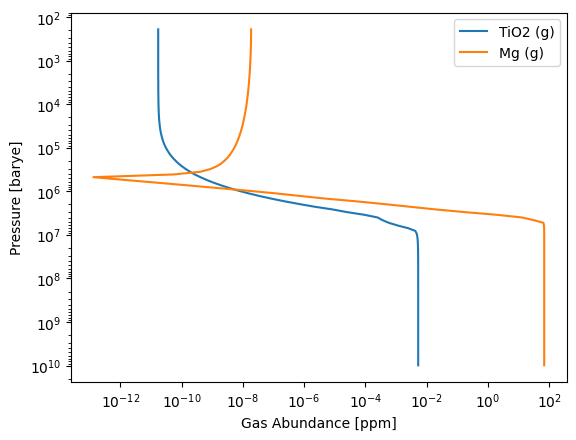

In [18]:
NT = -1

plt.plot(carma.results.gasses["TiO2"][:, NT], carma.results.P, label="TiO2 (g)")
plt.plot(carma.results.gasses["Mg2SiO4"][:, NT], carma.results.P, label="Mg (g)")

plt.xscale("log")
plt.yscale("log")
plt.gca().invert_yaxis()

plt.legend()
plt.ylabel("Pressure [barye]")
plt.xlabel("Gas Abundance [ppm]")

plt.show()

Note that the gas abundance is constant below the cloud base and then is depleted where the cloud formation occurs. 